In [4]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))

Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


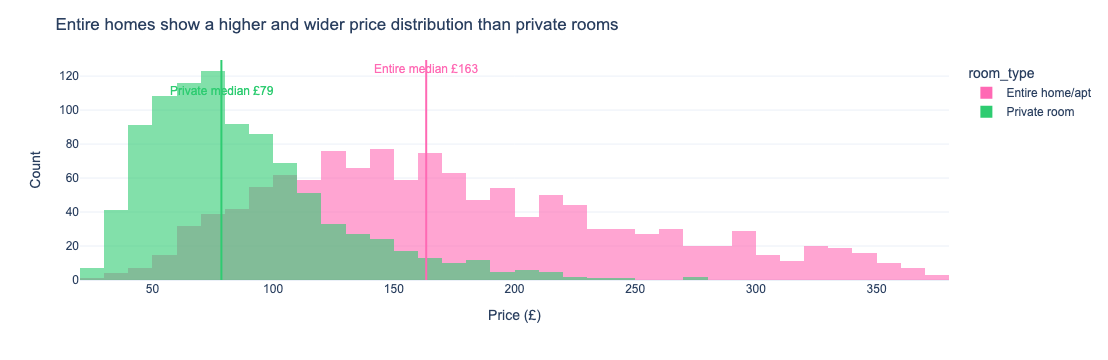

In [5]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]

subset = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

fig = px.histogram(
    subset,
    x="price",
    color="room_type",
    barmode="overlay",
    opacity=0.6,
    color_discrete_map={
        "Entire home/apt": "#FF69B4",
        "Private room": "#2ECC71"
    }
)

entire_median = subset[subset['room_type'] == 'Entire home/apt']['price'].median()
private_median = subset[subset['room_type'] == 'Private room']['price'].median()

fig.add_vline(
    x=entire_median,
    line_color="#FF69B4",
    line_width=2
)

fig.add_annotation(
    x=entire_median,
    y=1,
    yref="paper",
    text=f"Entire median £{entire_median:.0f}",
    showarrow=False,
    font=dict(color="#FF69B4")
)

fig.add_vline(
    x=private_median,
    line_color="#2ECC71",
    line_width=2
)

fig.add_annotation(
    x=private_median,
    y=0.9,
    yref="paper",
    text=f"Private median £{private_median:.0f}",
    showarrow=False,
    font=dict(color="#2ECC71")
)

fig.update_layout(
    title="Entire homes show a higher and wider price distribution than private rooms",
    xaxis_title="Price (£)",
    yaxis_title="Count",
    template="plotly_white",
    font=dict(family="Arial")
)

fig.show()

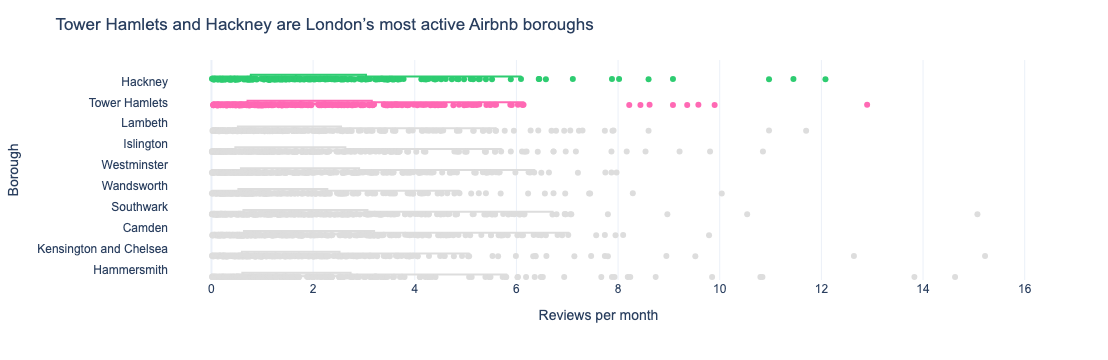

In [6]:
df_active = df[df['reviews_per_month'] > 0].copy()

borough_stats = df_active.groupby('neighbourhood')['reviews_per_month'].median().sort_values(ascending=False)
top2 = borough_stats.head(2).index.tolist()

df_active["highlight"] = df_active["neighbourhood"].apply(lambda x: x if x in top2 else "Other")

fig = px.box(
    df_active,
    y="neighbourhood",
    x="reviews_per_month",
    color="highlight",
    orientation="h",
    color_discrete_map={
        top2[0]: "#FF69B4",
        top2[1]: "#2ECC71",
        "Other": "#DDDDDD"
    },
    points="all"
)

fig.update_layout(
    title=f"{top2[0]} and {top2[1]} are London’s most active Airbnb boroughs",
    xaxis_title="Reviews per month",
    yaxis_title="Borough",
    template="plotly_white",
    font=dict(family="Arial"),
    showlegend=False
)

fig.show()